# Scylla Benchmarks

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
import re
import csv
from dataclasses import dataclass
from pathlib import Path

In [2]:
frinx = "Scylla"

def savefig(fig, name):
    out = (Path("graphs") / name).with_suffix(".pdf")
    fig.savefig(out, bbox_inches="tight")

## Fragging on Nym: Latency between fragments

In [43]:
testbed_path = Path("nym")
outputs_path = testbed_path / "shadow" / "outputs"

@dataclass
class Frag:
    sender: str
    chance: str
    delay: str
    run: int
    latency_ms: float

    def column(self):
        return int(self.chance[2]) - 1

def load_shadow_output_file(path: Path) -> [Frag]:
    frags = []
    match = re.match("delay_(...?)_chance_(...)_seed_(.)", path.stem)
    if match is None:
        return []
    delay = match.group(1)
    chance = match.group(2)
    run = int(match.group(3))

    with path.open() as fobj:
        for line in fobj:
            match = re.search('\\(sent by (\\w+)\\) is complete.+ (\\d+) milliseconds', line)
            if match is None:
                continue
            sender = match.group(1)
            latency = int(match.group(2))
            frag = Frag(sender=sender, chance=chance, delay=delay, run=run, latency_ms=latency)
            frags.append(frag)
    return frags

def load_shadow_output_files(path: Path) -> [Frag]:
    result = []
    for name in path.iterdir():
        result.extend(load_shadow_output_file(name))
    return result

frags = load_shadow_output_files(outputs_path)

FileNotFoundError: [Errno 2] No such file or directory: 'nym/shadow/outputs'

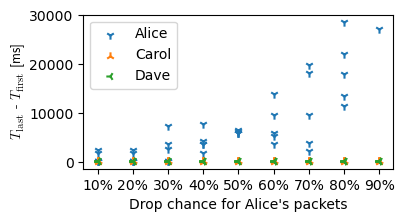

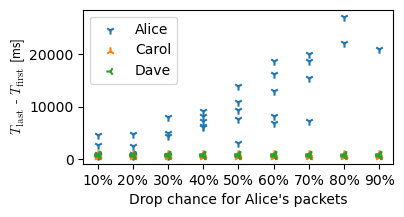

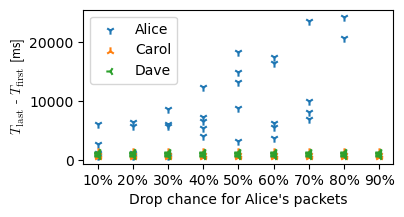

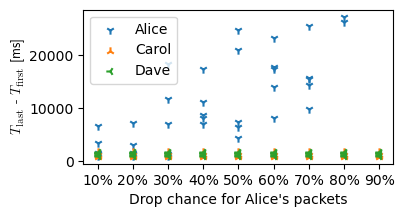

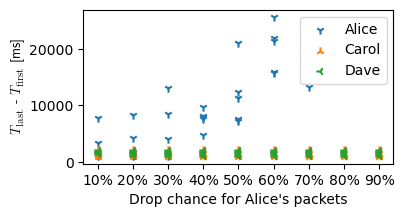

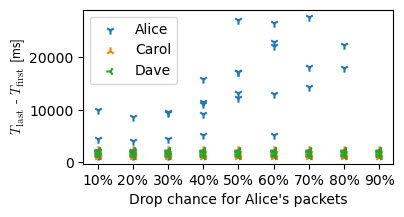

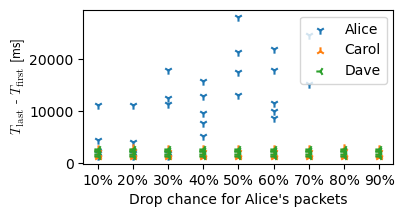

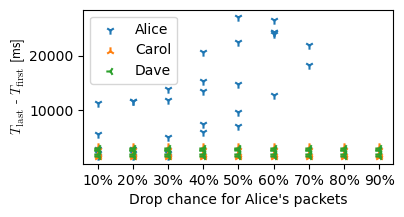

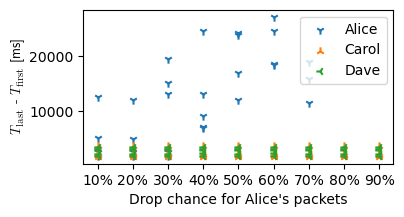

In [4]:
def plot_drop_chance_vs_latency(ax, delay="50"):
    fs = [f for f in frags if f.delay == delay]
    res_alice = [f for f in fs if f.sender == "alice"]
    x, y = [], []
    for frag in res_alice:
        x.append(frag.column())
        y.append(frag.latency_ms)
    ax.scatter(x, y, marker="1", label="Alice")

    res_carol = [f for f in fs if f.sender == "eve"]
    x, y = [], []
    for frag in res_carol:
        x.append(frag.column())
        y.append(frag.latency_ms)
    ax.scatter(x, y, marker="2", label="Carol")

    res_dave = [f for f in fs if f.sender == "someone"]
    x, y = [], []
    for frag in res_dave:
        x.append(frag.column())
        y.append(frag.latency_ms)
    ax.scatter(x, y, marker="3", label="Dave")

    ax.legend()
    ax.set_xticks(
        [0, 1, 2, 3, 4, 5, 6, 7, 8],
        [f"{x * 10}%" for x in range(1, 10)],
    )
    ax.set_xlabel("Drop chance for Alice's packets")
    ax.set_ylabel("\\(T_\\mathrm{last}\\) - \\(T_\\mathrm{first}\\) [ms]", usetex=True)

for delay in ["50", "150", "200", "250", "300", "350", "400", "450", "500"]:
    fig, ax = plt.subplots(figsize=(4, 2))
    plot_drop_chance_vs_latency(ax, delay=delay)
    savefig(fig, f"drop_chance_vs_latency_delay_{delay}")

## Per-Fragment ACK vs. Whole-Message ACK

In [65]:
@dataclass
class LatencySimResult:
    num_frags: int
    ack_strat: str
    drop_chance: float
    dt_avg: float
    dt_25: float
    dt_50: float
    dt_75: float
    ftl_avg: float
    ftl_25: float
    ftl_50: float
    ftl_75: float
    packet_count: int

def load_latency_sim(path: Path) -> list[LatencySimResult]:
    with open(path) as fo:
        reader = csv.DictReader(fo)
        return [
            LatencySimResult(
                int(l["num_frags"]),
                l["ack_strat"],
                float(l["drop_chance"]),
                float(l["dt_avg"]),
                float(l["dt_25"]),
                float(l["dt_50"]),
                float(l["dt_75"]),
                float(l["ftl_avg"]),
                float(l["ftl_25"]),
                float(l["ftl_50"]),
                float(l["ftl_75"]),
                int(l["packet_count"]),
            ) for l in reader
        ]

latency_sim = load_latency_sim("latency-sim/results.csv")

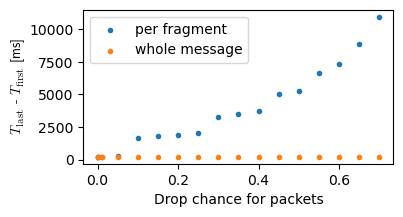

In [73]:
def plot_sim_drop_chance_vs_ftl(ax, num_frags):
    pfs = [r for r in latency_sim if r.ack_strat == "PerFragment" and r.num_frags == num_frags]
    pfs.sort(key=lambda r: r.drop_chance)

    wms = [r for r in latency_sim if r.ack_strat == "WholeMessage" and r.num_frags == num_frags]
    wms.sort(key=lambda r: r.drop_chance)

    xs = [r.drop_chance for r in pfs]
    ys_pf = [r.ftl_50 for r in pfs]
    ys_pf_lower = [r.ftl_50 - r.ftl_25 for r in pfs]
    ys_pf_upper = [r.ftl_75 - r.ftl_50 for r in pfs]
    ys_wm = [r.ftl_50 for r in wms]
    ys_wm_lower = [r.ftl_50 - r.ftl_25 for r in wms]
    ys_wm_upper = [r.ftl_75 - r.ftl_50 for r in wms]

    #ax.errorbar(xs, ys_pf, (ys_pf_lower, ys_pf_upper), fmt=".", label="per fragment")
    #ax.errorbar(xs, ys_wm, (ys_wm_lower, ys_wm_upper), fmt=".", label="whole message")
    ax.scatter(xs, ys_pf, marker=".", label="per fragment")
    ax.scatter(xs, ys_wm, marker=".", label="whole message")
    ax.legend()

    ax.set_xlabel("Drop chance for packets")
    ax.set_ylabel("\\(T_\\mathrm{last}\\) - \\(T_\\mathrm{first}\\) [ms]", usetex=True)

fig, ax = plt.subplots(figsize=(4, 2))
plot_sim_drop_chance_vs_ftl(ax, 8)
savefig(fig, "sim_drop_chance_vs_ftl")

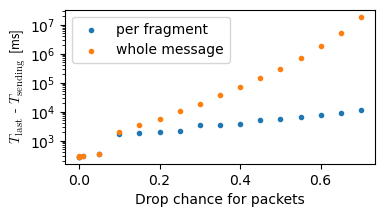

In [76]:
def plot_sim_drop_chance_vs_dt(ax, num_frags):
    pfs = [r for r in latency_sim if r.ack_strat == "PerFragment" and r.num_frags == num_frags]
    pfs.sort(key=lambda r: r.drop_chance)

    wms = [r for r in latency_sim if r.ack_strat == "WholeMessage" and r.num_frags == num_frags]
    wms.sort(key=lambda r: r.drop_chance)

    xs = [r.drop_chance for r in pfs]
    ys_pf = [r.dt_50 for r in pfs]
    ys_pf_lower = [r.dt_50 - r.dt_25 for r in pfs]
    ys_pf_upper = [r.dt_75 - r.dt_50 for r in pfs]
    ys_wm = [r.dt_50 for r in wms]
    ys_wm_lower = [r.dt_50 - r.dt_25 for r in wms]
    ys_wm_upper = [r.dt_75 - r.dt_50 for r in wms]

    #ax.errorbar(xs, ys_pf, (ys_pf_lower, ys_pf_upper), fmt=".", label="per fragment")
    #ax.errorbar(xs, ys_wm, (ys_wm_lower, ys_wm_upper), fmt=".", label="whole message")
    ax.scatter(xs, ys_pf, marker=".", label="per fragment")
    ax.scatter(xs, ys_wm, marker=".", label="whole message")
    ax.legend()

    ax.set_xlabel("Drop chance for packets")
    ax.set_ylabel("\\(T_\\mathrm{last}\\) - \\(T_\\mathrm{sending}\\) [ms]", usetex=True)

    ax.set_yscale("log")

fig, ax = plt.subplots(figsize=(4, 2))
plot_sim_drop_chance_vs_dt(ax, 8)
savefig(fig, "sim_drop_chance_vs_dt")

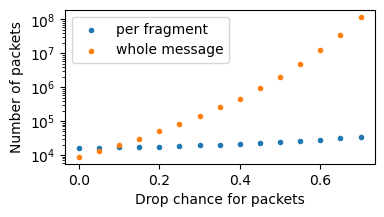

In [20]:
def plot_sim_drop_chance_vs_packet_count(ax, num_frags):
    pfs = [r for r in latency_sim if r.ack_strat == "PerFragment" and r.num_frags == num_frags]
    pfs.sort(key=lambda r: r.drop_chance)

    wms = [r for r in latency_sim if r.ack_strat == "WholeMessage" and r.num_frags == num_frags]
    wms.sort(key=lambda r: r.drop_chance)

    xs = [r.drop_chance for r in pfs]
    ys_pf = [r.packet_count for r in pfs]
    ys_wm = [r.packet_count for r in wms]

    ax.scatter(xs, ys_pf, marker=".", label="per fragment")
    ax.scatter(xs, ys_wm, marker=".", label="whole message")
    ax.legend()

    ax.set_xlabel("Drop chance for packets")
    ax.set_ylabel("Number of packets")

    ax.set_yscale("log")

fig, ax = plt.subplots(figsize=(4, 2))
plot_sim_drop_chance_vs_packet_count(ax, 8)
savefig(fig, "sim_drop_chance_vs_packet_count")

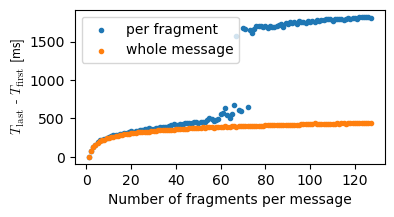

In [78]:
def plot_sim_fragment_count_vs_ftl(ax):
    pfs = [r for r in latency_sim if r.ack_strat == "PerFragment" and r.drop_chance == 0.01]
    pfs.sort(key=lambda r: r.num_frags)

    wms = [r for r in latency_sim if r.ack_strat == "WholeMessage" and r.drop_chance == 0.01]
    wms.sort(key=lambda r: r.num_frags)

    xs = [r.num_frags for r in pfs]
    ys_pf = [r.ftl_50 for r in pfs]
    ys_pf_lower = [max(0, r.ftl_50 - r.ftl_25) for r in pfs]
    ys_pf_upper = [max(0, r.ftl_75 - r.ftl_50) for r in pfs]
    ys_wm = [r.ftl_50 for r in wms]
    ys_wm_lower = [max(0, r.ftl_50 - r.ftl_25) for r in wms]
    ys_wm_upper = [max(0, r.ftl_75 - r.ftl_50) for r in wms]

    #ax.errorbar(xs, ys_pf, (ys_pf_lower, ys_pf_upper), fmt=".", label="per fragment")
    #ax.errorbar(xs, ys_wm, (ys_wm_lower, ys_wm_upper), fmt=".", label="whole message")
    ax.scatter(xs, ys_pf, marker=".", label="per fragment")
    ax.scatter(xs, ys_wm, marker=".", label="whole message")
    ax.legend()

    ax.set_xlabel("Number of fragments per message")
    ax.set_ylabel("\\(T_\\mathrm{last}\\) - \\(T_\\mathrm{first}\\) [ms]", usetex=True)

fig, ax = plt.subplots(figsize=(4, 2))
plot_sim_fragment_count_vs_ftl(ax)
savefig(fig, "sim_fragment_count_vs_ftl")

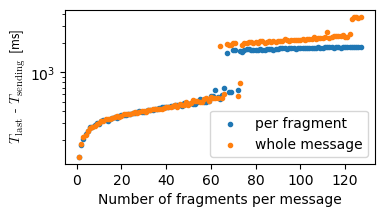

In [79]:
def plot_sim_fragment_count_vs_dt(ax, num_frags):
    pfs = [r for r in latency_sim if r.ack_strat == "PerFragment" and r.drop_chance == 0.01]
    pfs.sort(key=lambda r: r.num_frags)

    wms = [r for r in latency_sim if r.ack_strat == "WholeMessage" and r.drop_chance == 0.01]
    wms.sort(key=lambda r: r.num_frags)

    xs = [r.num_frags for r in pfs]
    ys_pf = [r.dt_50 for r in pfs]
    ys_pf_lower = [max(0, r.dt_50 - r.dt_25) for r in pfs]
    ys_pf_upper = [max(0, r.dt_75 - r.dt_50) for r in pfs]
    ys_wm = [r.dt_50 for r in wms]
    ys_wm_lower = [max(0, r.dt_50 - r.dt_25) for r in wms]
    ys_wm_upper = [max(0, r.dt_75 - r.dt_50) for r in wms]

    #ax.errorbar(xs, ys_pf, (ys_pf_lower, ys_pf_upper), fmt=".", label="per fragment")
    #ax.errorbar(xs, ys_wm, (ys_wm_lower, ys_wm_upper), fmt=".", label="whole message")
    ax.scatter(xs, ys_pf, marker=".", label="per fragment")
    ax.scatter(xs, ys_wm, marker=".", label="whole message")
    ax.legend()

    ax.set_xlabel("Number of fragments per message")
    ax.set_ylabel("\\(T_\\mathrm{last}\\) - \\(T_\\mathrm{sending}\\) [ms]", usetex=True)

    ax.set_yscale("log")

fig, ax = plt.subplots(figsize=(4, 2))
plot_sim_fragment_count_vs_dt(ax, 8)
savefig(fig, "sim_fragment_count_vs_dt")

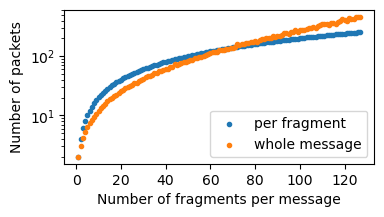

In [58]:
def plot_sim_fragment_count_vs_packet_count(ax):
    pfs = [r for r in latency_sim if r.ack_strat == "PerFragment" and r.drop_chance == 0.01]
    pfs.sort(key=lambda r: r.num_frags)

    wms = [r for r in latency_sim if r.ack_strat == "WholeMessage" and r.drop_chance == 0.01]
    wms.sort(key=lambda r: r.num_frags)

    xs = [r.num_frags for r in pfs]
    ys_pf = [r.packet_count / 1000 for r in pfs]
    ys_wm = [r.packet_count / 1000 for r in wms]

    ax.scatter(xs, ys_pf, marker=".", label="per fragment")
    ax.scatter(xs, ys_wm, marker=".", label="whole message")
    ax.legend()

    ax.set_xlabel("Number of fragments per message")
    ax.set_ylabel("Number of packets")

    ax.set_yscale("log")

fig, ax = plt.subplots(figsize=(4, 2))
plot_sim_fragment_count_vs_packet_count(ax)
savefig(fig, "sim_fragment_count_vs_packet_count")

## Computation time

In [26]:
@dataclass
class Result:
    name: str
    mean: float
    lower_bound: float
    upper_bound: float

    @property
    def mean_ms(self):
        return self.mean / 1000000

    @property
    def mean_mus(self):
        return self.mean / 1000

    @property
    def lower_bound_ms(self):
        return self.lower_bound / 1000000

    @property
    def lower_bound_mus(self):
        return self.lower_bound / 1000

    @property
    def upper_bound_ms(self):
        return self.upper_bound / 1000000

    @property
    def upper_bound_mus(self):
        return self.upper_bound / 1000

    def matches(self, regex):
        return re.match(regex, self.name)

    @staticmethod
    def load_json(path):
        meta = json.loads((path / "new" / "benchmark.json").read_text())
        estimates = json.loads((path / "new" / "estimates.json").read_text())
        result = Result(
            name=meta["group_id"],
            mean=estimates["mean"]["point_estimate"],
            lower_bound=estimates["mean"]["confidence_interval"]["lower_bound"],
            upper_bound=estimates["mean"]["confidence_interval"]["upper_bound"],
        )
        return result

def load_frinx_results(path: Path) -> [Result]:
    results = []
    for bench in path.iterdir():
        if (bench / "new").exists():
            result = Result.load_json(bench)
            results.append(result)
    return results

def load_sphinx_results(path: Path) -> [Result]:
    results = []
    for folder in path.iterdir():
        if m := re.match('length_(\\d+)', folder.name):
            length = int(m.group(1))
            for inner in folder.iterdir():
                if (inner / "new").exists():
                    result = Result.load_json(inner)
                    result.name = f"{result.name} ({length})"
                    results.append(result)
    return results

In [43]:
frinx_results = load_frinx_results(Path("scylla/target/criterion"))
sphinx_results = load_sphinx_results(Path("sphinx-benchmarks/target/criterion"))

### Creation times

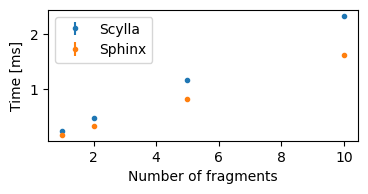

In [44]:
def plot_fragment_count_vs_creation_time(ax):
    payload_size = 128
    path_length = 3

    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::create_onions\\({path_length}, {payload_size}, (\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label=frinx)

    ys = []
    y_low = []
    y_high = []

    for result in sphinx_results:
        if match := result.matches(f"sphinx creation \\({payload_size}\\) \\({path_length}\\)"):
            for x in xs:
                ys.append(x * result.mean_ms)
                y_low.append(x * (result.mean_ms - result.lower_bound_ms))
                y_high.append(x * (result.upper_bound_ms - result.mean_ms))

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label="Sphinx")

    ax.set_xlabel("Number of fragments")
    ax.set_ylabel("Time [ms]")
    ax.legend()

fig, ax = plt.subplots(figsize=(4, 1.7))
plot_fragment_count_vs_creation_time(ax)
savefig(fig, "fragment_count_vs_creation_time")

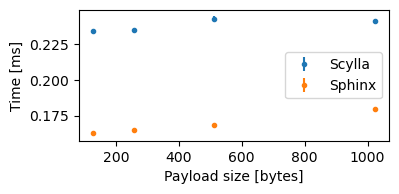

In [45]:
def plot_payload_size_vs_creation_time(ax):
    fragment_count = 1
    path_length = 3

    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::create_onions\\({path_length}, (\\d+), {fragment_count}\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label=frinx)

    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in sphinx_results:
        if match := result.matches(f"sphinx creation \\((\\d+)\\) \\({path_length}\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label="Sphinx")

    ax.set_xlabel("Payload size [bytes]")
    ax.set_ylabel("Time [ms]")
    ax.legend()

fig, ax = plt.subplots(figsize=(4, 1.7))
plot_payload_size_vs_creation_time(ax)
savefig(fig, "payload_size_vs_creation_time")

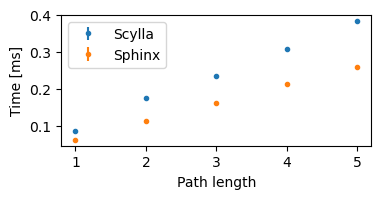

In [46]:
def plot_path_length_vs_creation_time(ax):
    fragment_count = 1
    payload_size = 128

    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::create_onions\\((\\d+), {payload_size}, {fragment_count}\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label=frinx)

    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in sphinx_results:
        if match := result.matches(f"sphinx creation \\({payload_size}\\) \\((\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label="Sphinx")

    ax.set_xlabel("Path length")
    ax.set_ylabel("Time [ms]")
    ax.legend()

fig, ax = plt.subplots(figsize=(4, 1.7))
plot_path_length_vs_creation_time(ax)
savefig(fig, "path_length_vs_creation_time")

### Processing time

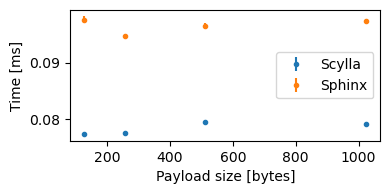

In [47]:
def plot_payload_size_vs_processing_time(ax):
    xs = []
    ys = []
    y_low = []
    y_high = []
    
    for result in frinx_results:
        if match := result.matches(f"Scylla::process\\(Flag::Relay, (\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label=frinx)

    xs = []
    ys = []
    y_low = []
    y_high = []
    
    for result in sphinx_results:
        if match := result.matches(f"sphinx unwrap \\((\\d+)\\) \\(3\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label="Sphinx")
    ax.set_xlabel("Payload size [bytes]")
    ax.set_ylabel("Time [ms]")
    ax.legend()
    
fig, ax = plt.subplots(figsize=(4, 1.7))
plot_payload_size_vs_processing_time(ax)
savefig(fig, "payload_size_vs_processing_time")

In [11]:
def print_processing_times_fragment_deliver():
    for result in frinx_results:
        if match := result.matches(f"Scylla::process\\(Flag::(Deliver|Fragment), (\\d+)\\)"):
            print("{} {} bytes: {} ms".format(match.group(1), match.group(2), result.mean_ms))
            
print_processing_times_fragment_deliver()

Fragment 128 bytes: 0.03964538839349798 ms
Deliver 128 bytes: 0.03965432119193411 ms
Fragment 256 bytes: 0.03984512691149239 ms
Deliver 256 bytes: 0.039774293351178075 ms
Fragment 512 bytes: 0.04056202131999518 ms
Deliver 512 bytes: 0.04023306447312047 ms
Fragment 1024 bytes: 0.04033100903221699 ms
Deliver 1024 bytes: 0.04032611323001156 ms


### Reassembly time

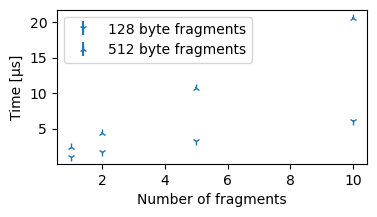

In [48]:
def plot_fragment_count_vs_reassembly_time(ax):
    payload_size = 128

    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::defrag\\({payload_size}, (\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_mus)
            y_low.append(result.mean_mus - result.lower_bound_mus)
            y_high.append(result.upper_bound_mus - result.mean_mus)

    ax.errorbar(xs, ys, (y_low, y_high), label=f"{payload_size} byte fragments", fmt="1")

    payload_size = 512

    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::defrag\\({payload_size}, (\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_mus)
            y_low.append(result.mean_mus - result.lower_bound_mus)
            y_high.append(result.upper_bound_mus - result.mean_mus)

    ax.errorbar(xs, ys, (y_low, y_high), label=f"{payload_size} byte fragments", fmt="2", color="tab:blue")

    ax.set_xlabel("Number of fragments")
    ax.set_ylabel("Time [μs]")

    ax.legend()

fig, ax = plt.subplots(figsize=(4, 2))
plot_fragment_count_vs_reassembly_time(ax)
savefig(fig, "fragment_count_vs_reassembly_time")

### SURB creation

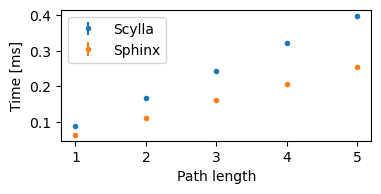

In [49]:
def plot_path_length_vs_surb_creation(ax):
    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::create_surb\\((\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label=frinx)

    xs = []
    ys = []
    y_low = []
    y_high = []

    for result in sphinx_results:
        if match := result.matches(f"sphinx surb \\((\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)
            y_low.append(result.mean_ms - result.lower_bound_ms)
            y_high.append(result.upper_bound_ms - result.mean_ms)

    ax.errorbar(xs, ys, (y_low, y_high), fmt=".", label="Sphinx")

    ax.set_xlabel("Path length")
    ax.set_ylabel("Time [ms]")

    ax.legend()

fig, ax = plt.subplots(figsize=(4, 1.7))
plot_path_length_vs_surb_creation(ax)
savefig(fig, "path_length_vs_surb_creation")

## Packet sizes

In [4]:
def int_values(obj):
    return {k: int(v) for k, v in obj.items()}

with open(Path("scylla") / "onion_sizes.csv", "r") as inf:
    frinx_sizes = [int_values(o) for o in csv.DictReader(inf)]
with open(Path("sphinx-benchmarks") / "sphinx_onion_sizes.csv", "r") as inf:
    sphinx_sizes = [int_values(o) for o in csv.DictReader(inf)]

def fil(l, **attrs):
    return [item for item in l if all(item[k] == v for k, v in attrs.items())]

def get(l, **attrs):
    res = fil(l, **attrs)
    if res:
        return res[0]
    return None

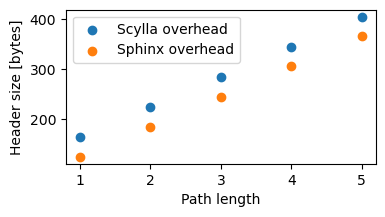

In [8]:
def plot_path_length_vs_onion_size(ax):
    xs = []
    ys = []

    for result in fil(frinx_sizes, fragment_count=1, payload_size=128):
        xs.append(result["path_length"])
        # add 64 bytes for OAEP, recipient and auth bytes
        ys.append(result["onion_size"] - 128 + 64)
        
    ax.scatter(xs, ys, label=f"{frinx} overhead")

    xs = []
    ys = []

    for result in fil(sphinx_sizes, payload_size=512):
        xs.append(result["path_length"])
        ys.append(result["onion_size"] - 512)

    ax.scatter(xs, ys, label="Sphinx overhead")

    ax.set_xlabel("Path length")
    ax.set_ylabel("Header size [bytes]")
    ax.legend()

fig, ax = plt.subplots(figsize=(4, 2))
plot_path_length_vs_onion_size(ax)
savefig(fig, "path_length_vs_onion_size")